#Importing and Inspecting Dataset

## Connect colab to google drive




In [ ]:

from google.colab import drive
drive.mount('content/gdrive', force_remount= True)
%cd "content/gdrive"


Mounted at /gdrive
/gdrive/My Drive/[2024-2025] AN2DL


## ⚙️ Import Libraries


In [ ]:
seed = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import matplotlib.gridspec as gridspec

# Set seeds for random number generators in NumPy and Python
np.random.seed(seed)
random.seed(seed)

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
from tensorflow.keras.utils import to_categorical

# Set seed for TensorFlow
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

# Reduce TensorFlow verbosity
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Print TensorFlow version
print(tf.__version__)

# Import other libraries
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

2.17.1


## Importing data set


In [ ]:

#Importing the data set

data = np.load("/gdrive/My Drive/[2024-2025] AN2DL/Homework 1/training_set.npz")
X_train_val = data['images']
Y_train_val = data['labels']


## Inspect data


Training-Validation Data Shape: (13759, 96, 96, 3)
Training-Validation Label Shape: (13759, 1)
Number of unique labels: (8,)
0 :  1052
1 :  2381
2 :  1285
3 :  2226
4 :  1049
5 :  1393
6 :  2530
7 :  1843


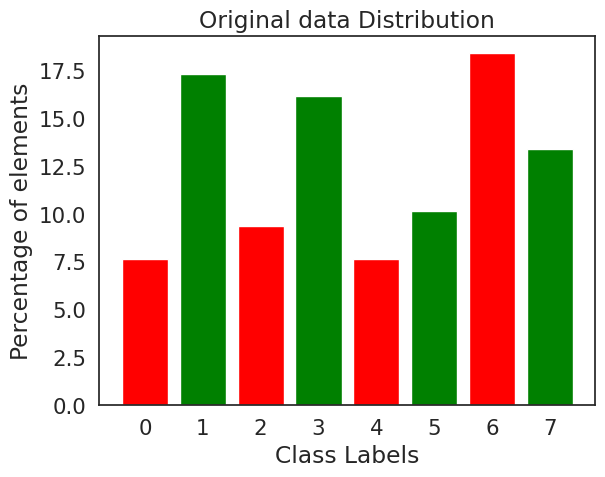

In [ ]:

# Print the shapes of the loaded datasets
#Labels: 0: 'Basophil', 1:'Eosinophil', 2:'Erythroblas', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelets'
print("Training-Validation Data Shape:", X_train_val.shape)
print("Training-Validation Label Shape:", Y_train_val.shape)
print("Number of unique labels:", np.unique(Y_train_val).shape)

unique_labels = np.unique(Y_train_val)
n_elements = []
ratio_elements = []
labels = []
tot_elements = Y_train_val.shape[0]
for label in np.unique(Y_train_val):
  labels.append(label)
  n_elements.append(np.count_nonzero(Y_train_val == label))
  print(label,": ", n_elements[label])
# labels for bars
tick_label = [0, 1, 2, 3, 4, 5, 6, 7]

ratio_elements = 100*np.array(n_elements)/tot_elements

# plotting a bar chart
plt.bar(labels, ratio_elements, tick_label = tick_label,width = 0.8, color = ['red', 'green'])

# naming the x-axis
plt.xlabel('Class Labels', )
# naming the y-axis
plt.ylabel('Percentage of elements')
# plot title
plt.title('Original data Distribution')

# function to show the plot
plt.show()


## Print a few images in order to know how to augment them

In [ ]:

# Set up the plot to display the images
fig, axes = plt.subplots(len(unique_labels), 5, figsize=(15, len(unique_labels) * 3))

# Loop through each label
for i, label in enumerate(unique_labels):
    # Get the indices of the images that correspond to the current label
    label_indices = np.where(Y_train_val == label)[0]

    # Randomly select 5 indices for the current label
    random_indices = np.random.choice(label_indices, 5, replace=False)

    # Select and display 5 random images for the current label
    for j in range(5):
        image = X_train_val[random_indices[j]]
        # Display the image
        ax = axes[i, j]
        ax.imshow(image)
        ax.axis('off')  # Hide the axis
        ax.set_title(f'Label: {label}')

# Adjust the layout and show the images
plt.tight_layout()
plt.show()


#Retrieval


## Shrek Retrieval

(-0.5, 95.5, 95.5, -0.5)

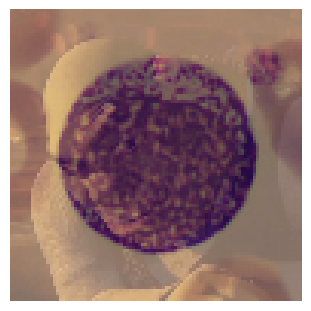

In [ ]:
#Inspecting the dataset by means of random estractions, we discovered that the image with index 12869 was one of the ones contaminated with the image of Shrek
shrek_image = X_train_val[12869]
fig = plt.figure(constrained_layout=True, figsize=(12, 3))
gs = gridspec.GridSpec(1, 1, figure=fig, width_ratios=[1], wspace=0.1)
ax1 = fig.add_subplot(gs[0])
ax1.imshow(np.squeeze(shrek_image))
ax1.axis('off')


## Rick Astley Retrieval

(-0.5, 95.5, 95.5, -0.5)

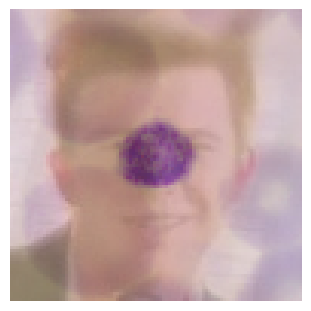

In [ ]:
#Inspecting the dataset by means of random estractions, we discovered that the image with index 13561 was one of the ones contaminated with the image of Rick Astley
rick_image = X_train_val[13561]
fig = plt.figure(constrained_layout=True, figsize=(12, 3))
gs = gridspec.GridSpec(1, 1, figure=fig, width_ratios=[1], wspace=0.1)
ax1 = fig.add_subplot(gs[0])
ax1.imshow(np.squeeze(rick_image))
ax1.axis('off')


#Dataset Cleaning

##Image Cleaning

Contaminated image indices: [11959, 11960, 11961, 11962, 11963, 11964, 11965, 11966, 11967, 11968, 11969, 11970, 11971, 11972, 11973, 11974, 11975, 11976, 11977, 11978, 11979, 11980, 11981, 11982, 11983, 11984, 11985, 11986, 11987, 11988, 11989, 11990, 11991, 11992, 11993, 11994, 11995, 11996, 11997, 11998, 11999, 12000, 12001, 12002, 12003, 12004, 12005, 12006, 12007, 12008, 12009, 12010, 12011, 12012, 12013, 12014, 12015, 12016, 12017, 12018, 12019, 12020, 12021, 12022, 12023, 12024, 12025, 12026, 12027, 12028, 12029, 12030, 12031, 12032, 12033, 12034, 12035, 12036, 12037, 12038, 12039, 12040, 12041, 12042, 12043, 12044, 12045, 12046, 12047, 12048, 12049, 12050, 12051, 12052, 12053, 12054, 12055, 12056, 12057, 12058, 12059, 12060, 12061, 12062, 12063, 12064, 12065, 12066, 12067, 12068, 12069, 12070, 12071, 12072, 12073, 12074, 12075, 12076, 12077, 12078, 12079, 12080, 12081, 12082, 12083, 12084, 12085, 12086, 12087, 12088, 12089, 12090, 12091, 12092, 12093, 12094, 12095, 12096, 12097

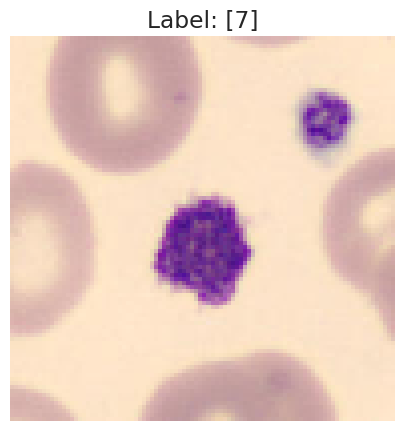

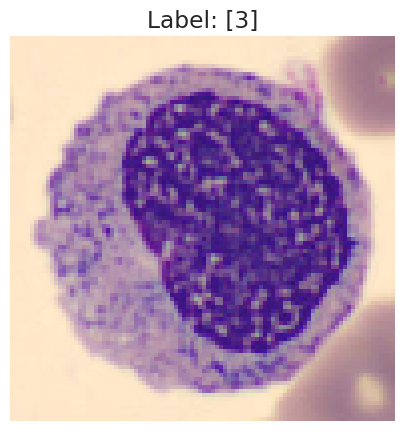

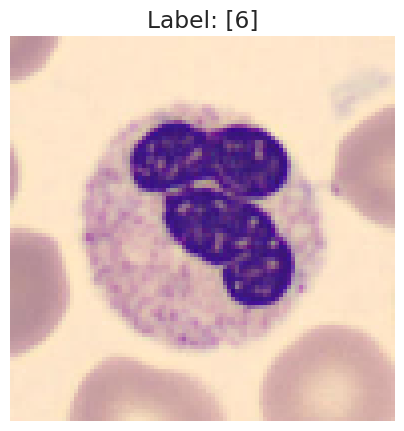

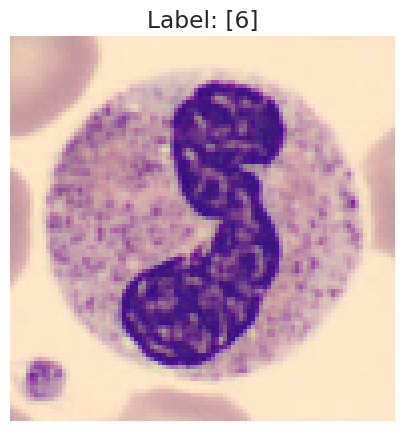

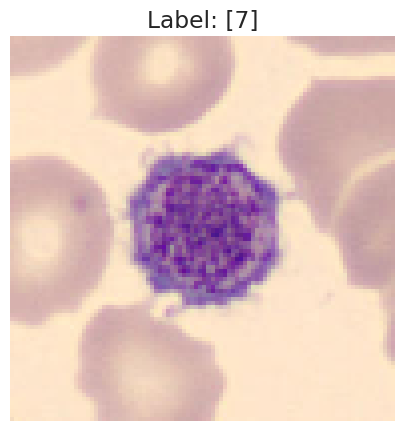

In [ ]:
# List to hold indices of images to be deleted
delete_indices = []

# Loop through all images from start_index to the end
for index in range(X_train_val.shape[0]):
    # Check if the image is contaminated (compare with 'shrek_image' or 'rick_image')
    if np.array_equal(shrek_image, X_train_val[index]) or np.array_equal(rick_image, X_train_val[index]):
        delete_indices.append(index)

# Print the indices of contaminated images
print("Contaminated image indices:", delete_indices)

# Delete the contaminated images in one go
if delete_indices:
    delete_indices = np.array(delete_indices)
    print(delete_indices)
    X_train_val = np.delete(X_train_val, delete_indices, axis=0)
    Y_train_val = np.delete(Y_train_val, delete_indices, axis=0)

# Print updated shapes of X_train_val and Y_train_val
print(f"Updated X_train_val shape: {X_train_val.shape}")
print(f"Updated Y_train_val shape: {Y_train_val.shape}")

# Visualize some of the images
for i in range(min(5, X_train_val.shape[0])):  # Show the first 5 images after deletion
    plt.figure(figsize=(5, 5))
    plt.imshow(X_train_val[i])  # Display image
    plt.title(f"Label: {Y_train_val[i]}")
    plt.axis('off')
    plt.show()


## Second data inspection after image cleaning


Training-Validation Data Shape: (11959, 96, 96, 3)
Training-Validation Label Shape: (11959, 1)
Number of unique labels: (8,)
0 :  852
1 :  2181
2 :  1085
3 :  2026
4 :  849
5 :  993
6 :  2330
7 :  1643


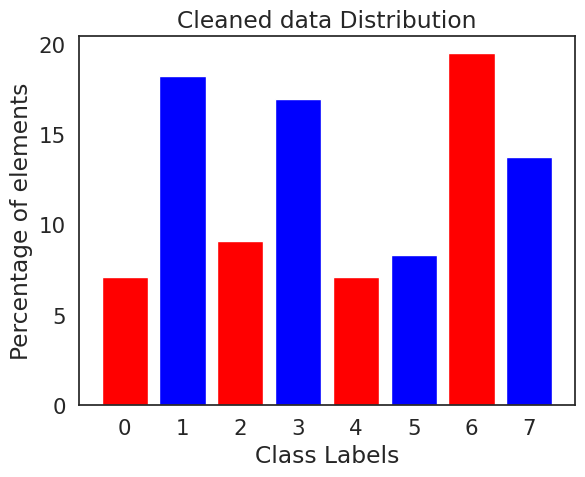

In [ ]:

# Print the shapes of the loaded datasets
#Labels: 0: 'Basophil', 1:'Eosinophil', 2:'Erythroblas', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelets'
print("Training-Validation Data Shape:", X_train_val.shape)
print("Training-Validation Label Shape:", Y_train_val.shape)
print("Number of unique labels:", np.unique(Y_train_val).shape)

unique_labels = np.unique(Y_train_val)
n_elements = []
ratio_elements = []
labels = []
tot_elements = Y_train_val.shape[0]
for label in np.unique(Y_train_val):
  labels.append(label)
  n_elements.append(np.count_nonzero(Y_train_val == label))
  print(label,": ", n_elements[label])
# labels for bars
tick_label = [0, 1, 2, 3, 4, 5, 6, 7]

ratio_elements = 100*np.array(n_elements)/tot_elements

# plotting a bar chart
plt.bar(labels, ratio_elements, tick_label = tick_label,width = 0.8, color = ['red', 'blue'])

# naming the x-axis
plt.xlabel('Class Labels', )
# naming the y-axis
plt.ylabel('Percentage of elements')
# plot title
plt.title('Cleaned data Distribution')

# function to show the plot
plt.show()


#Separation of the dataset

## Threshold Based Validation set






In [ ]:

def stratified_split_custom(X, Y, high_validation_percent, low_validation_percent, threshold):
    # Get unique class labels and initialize the split containers
    X_train, X_val, Y_train, Y_val = [], [], [], []

    tot_num_samples = X.shape[0]


    # Loop through each label and apply the custom splitting logic
    for label in unique_labels:
        # Get the indices of samples that belong to the current label
        class_indices = np.where(Y == label)[0]
        num_samples = len(class_indices)
        percent_num_sample = num_samples/tot_num_samples

        # If the number of samples exceeds the threshold percentage, apply validation_percent
        if percent_num_sample > threshold:
            num_val_samples = int(num_samples * high_validation_percent)
            val_indices = np.random.choice(class_indices, num_val_samples, replace=False)
            train_indices = np.setdiff1d(class_indices, val_indices)
        else:
            # If the class size is small, use a smaller number for validation, depending on the actual size
            num_val_samples = int(num_samples * low_validation_percent)  # Use half of the validation percent
            val_indices = np.random.choice(class_indices, num_val_samples, replace=False)
            train_indices = np.setdiff1d(class_indices, val_indices)

        # Append the samples to the final training and validation sets
        X_train.append(X[train_indices])
        Y_train.append(Y[train_indices])
        X_val.append(X[val_indices])
        Y_val.append(Y[val_indices])

    # Concatenate the lists to form the final train and validation sets
    X_train = np.concatenate(X_train, axis=0)
    Y_train = np.concatenate(Y_train, axis=0)
    X_val = np.concatenate(X_val, axis=0)
    Y_val = np.concatenate(Y_val, axis=0)

    return X_train, X_val, Y_train, Y_val

# Call the custom split function with a validation percent of 0.2 and threshold of 10% for each class
X_train, X_val, Y_train, Y_val = stratified_split_custom(X_train_val, Y_train_val, high_validation_percent=0.26, low_validation_percent=0.34, threshold = 0.1)

## Data Inspection after separation of the dataset

Training set shape: (8552, 96, 96, 3)
Validation set shape: (3407, 96, 96, 3)
Training Set Distribution:
Class 0: 563 samples
Class 1: 1614 samples
Class 2: 717 samples
Class 3: 1500 samples
Class 4: 561 samples
Class 5: 656 samples
Class 6: 1725 samples
Class 7: 1216 samples

Validation Set Distribution:
Class 0: 289 samples
Class 1: 567 samples
Class 2: 368 samples
Class 3: 526 samples
Class 4: 288 samples
Class 5: 337 samples
Class 6: 605 samples
Class 7: 427 samples


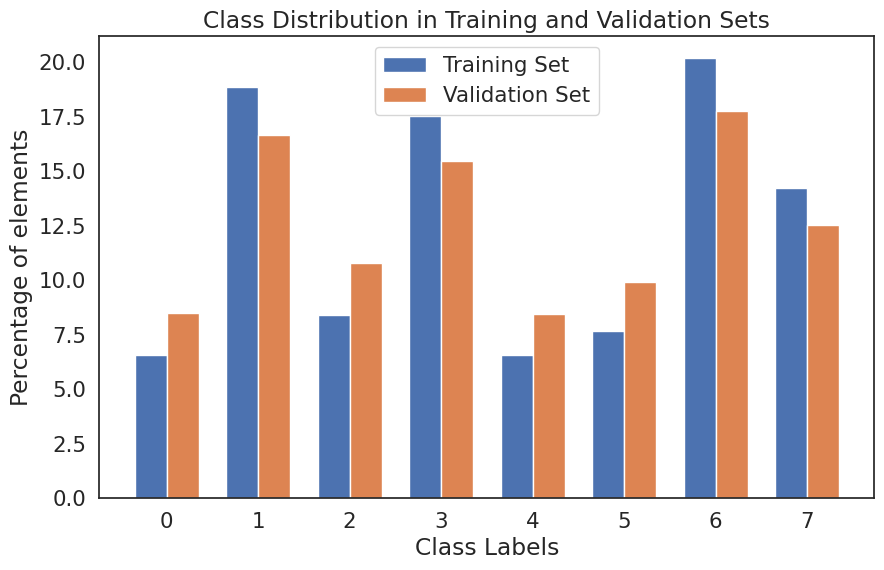

Training percent: 0.7151099590266745
Validation percent: 0.28489004097332554


In [ ]:
# Print the shape of the resulting datasets
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")


# Function to calculate the class distribution
def plot_class_distribution(X_train, Y_train, X_val, Y_val):

    # Calculate the number of samples per class in the training and validation sets
    n_elements_train = [np.count_nonzero(Y_train == label) for label in unique_labels]
    n_elements_val = [np.count_nonzero(Y_val == label) for label in unique_labels]

    tot_elements_train = len(Y_train)
    tot_elements_val = len(Y_val)

    # Print the number of elements for each class in the training and validation sets
    print("Training Set Distribution:")
    for label, n in zip(unique_labels, n_elements_train):
        print(f"Class {label}: {n} samples")

    print("\nValidation Set Distribution:")
    for label, n in zip(unique_labels, n_elements_val):
        print(f"Class {label}: {n} samples")

    # Calculate the percentage of each class
    ratio_train = 100 * np.array(n_elements_train) / tot_elements_train
    ratio_val = 100 * np.array(n_elements_val) / tot_elements_val

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Bars for the training and validation sets
    width = 0.35  # the width of the bars
    labels = unique_labels

    ax.bar(labels - width/2, ratio_train, width, label='Training Set')
    ax.bar(labels + width/2, ratio_val, width, label='Validation Set')

    # Add labels and title
    ax.set_xlabel('Class Labels')
    ax.set_ylabel('Percentage of elements')
    ax.set_title('Class Distribution in Training and Validation Sets')
    ax.set_xticks(labels)
    ax.set_xticklabels(labels)

    # Legend
    ax.legend()

    # Show the plot
    plt.show()

# Call the plot function to visualize the class distribution
plot_class_distribution(X_train, Y_train, X_val, Y_val)

print(f"Training percent: {X_train.shape[0]/X_train_val.shape[0]}")
print(f"Validation percent: {X_val.shape[0]/X_train_val.shape[0]}")



## Separation of the Validation set

In [ ]:

def validation_set_split(X_val, Y_val, test_normal_percent, test_augmented_percent, unique_labels):
    # Initialize lists for storing the split data
    X_test_normal = []
    Y_test_normal = []
    X_test_augmented = []
    Y_test_augmented = []
    X_val_final = []
    Y_val_final = []

    # Loop through each label and split the validation set
    for label in unique_labels:
        # Get the indices for the current label in the validation set
        tot_indeces = np.where(Y_val == label)[0]

        # Calculate how many samples to select for each set
        num_samples = len(tot_indeces)
        num_normal_samples = int(test_normal_percent * num_samples)
        num_augmented_samples = int(test_augmented_percent * num_samples)

        # Select normal test samples
        normal_indeces = np.random.choice(tot_indeces, num_normal_samples, replace=False)

        # Update the remaining indices by removing the normal ones
        remaining_indeces = np.setdiff1d(tot_indeces, normal_indeces)

        # Select augmented test samples from the remaining indices
        augmented_indeces = np.random.choice(remaining_indeces, num_augmented_samples, replace=False)

        # Update the final validation set by removing the augmented ones
        final_indeces = np.setdiff1d(remaining_indeces, augmented_indeces)

        # Append the splits to the corresponding lists
        X_test_normal.append(X_val[normal_indeces])
        Y_test_normal.append(Y_val[normal_indeces])
        X_test_augmented.append(X_val[augmented_indeces])
        Y_test_augmented.append(Y_val[augmented_indeces])
        X_val_final.append(X_val[final_indeces])
        Y_val_final.append(Y_val[final_indeces])

    # Concatenate the lists to form the final datasets
    X_test_normal = np.concatenate(X_test_normal, axis=0)
    Y_test_normal = np.concatenate(Y_test_normal, axis=0)
    X_test_augmented = np.concatenate(X_test_augmented, axis=0)
    Y_test_augmented = np.concatenate(Y_test_augmented, axis=0)
    X_val_final = np.concatenate(X_val_final, axis=0)
    Y_val_final = np.concatenate(Y_val_final, axis=0)

    return X_test_normal, Y_test_normal, X_test_augmented, Y_test_augmented, X_val_final, Y_val_final

X_test_normal, Y_test_normal, X_test_augmented, Y_test_augmented, X_val_final, Y_val_final = validation_set_split(X_val, Y_val, test_normal_percent=0.2, test_augmented_percent=0.2, unique_labels=unique_labels)

## Data Inspection for the validation set

In [ ]:
print(f"Validation set shape: {X_val_final.shape}")
print(f"Normal Test set shape: {X_test_normal.shape}")
print(f"Augemented Test set shape: {X_test_augmented.shape}")

n_elements_val = [np.count_nonzero(Y_val_final == label) for label in unique_labels]
n_elements_test_norm = [np.count_nonzero(Y_test_normal == label) for label in unique_labels]
n_elements_test_aug = [np.count_nonzero(Y_test_augmented == label) for label in unique_labels]

print("\nValidation Set Distribution:")
for label, n in zip(unique_labels, n_elements_val):
    print(f"Class {label}: {n} samples")

print("\nNormal Test Set Distribution:")
for label, n in zip(unique_labels, n_elements_test_norm):
    print(f"Class {label}: {n} samples")

print("\nAugmented Test Set Distribution:")
for label, n in zip(unique_labels, n_elements_test_aug):
    print(f"Class {label}: {n} samples")


Validation set shape: (2051, 96, 96, 3)
Normal Test set shape: (678, 96, 96, 3)
Augemented Test set shape: (678, 96, 96, 3)

Validation Set Distribution:
Class 0: 175 samples
Class 1: 341 samples
Class 2: 222 samples
Class 3: 316 samples
Class 4: 174 samples
Class 5: 203 samples
Class 6: 363 samples
Class 7: 257 samples

Normal Test Set Distribution:
Class 0: 57 samples
Class 1: 113 samples
Class 2: 73 samples
Class 3: 105 samples
Class 4: 57 samples
Class 5: 67 samples
Class 6: 121 samples
Class 7: 85 samples

Augmented Test Set Distribution:
Class 0: 57 samples
Class 1: 113 samples
Class 2: 73 samples
Class 3: 105 samples
Class 4: 57 samples
Class 5: 67 samples
Class 6: 121 samples
Class 7: 85 samples


## Saving Dataset

In [ ]:
# Function to save the dataset in a specific folder
def save_dataset(dataset, labels, file_name, folder_path):
    """
    Saves the dataset and labels in a .npz file in the specified folder.

    Parameters:
    - dataset: The dataset to save (NumPy array)
    - labels: The labels corresponding to the dataset (NumPy array)
    - file_name: Name of the file to be created (without extension)
    - folder_path: The path to the destination folder
    """

    # Check if the folder exists, otherwise create it
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    # Define the full path of the file
    file_path = os.path.join(folder_path, file_name + '.npz')

    # Save the dataset and labels as a .npz file
    np.savez(file_path, data=dataset, labels=labels)
    print(f"Dataset saved in: {file_path}")

# Destination folder on Google Drive
folder_path_training = "/gdrive/My Drive/FirstChallenge/splitting dataset/training"
folder_path_eff_validation = "/gdrive/My Drive/FirstChallenge/splitting dataset/validation/eff_validation"
folder_path_augmented_test_set = "/gdrive/My Drive/FirstChallenge/splitting dataset/validation/augmented_test_set"
folder_path_test_set = "/gdrive/My Drive/FirstChallenge/splitting dataset/validation/test_set"

# Call the function to save the dataset
save_dataset(X_train, Y_train, "training_set", folder_path_training)
save_dataset(X_val_final, Y_val_final, "eff_validation", folder_path_eff_validation)
save_dataset(X_test_augmented, Y_test_augmented, "augmented_test_set", folder_path_augmented_test_set)
save_dataset(X_test_normal, Y_test_normal, "test_set", folder_path_test_set)


'\n# Cartella di destinazione su Google Drive\nfolder_path_training = "/gdrive/My Drive/FirstChallenge/splitting dataset/training"\nfolder_path_eff_validation = "/gdrive/My Drive/FirstChallenge/splitting dataset/validation/eff_validation"\nfolder_path_augmented_test_set = "/gdrive/My Drive/FirstChallenge/splitting dataset/validation/augmented_test_set"\nfolder_path_test_set = "/gdrive/My Drive/FirstChallenge/splitting dataset/validation/test_set"\n\n# Chiamata alla funzione per salvare il dataset\nsave_dataset(X_train, Y_train, "training_set", folder_path_training )\nsave_dataset(X_val_final, Y_val_final, "eff_validation", folder_path_eff_validation)\nsave_dataset(X_test_augmented, Y_test_augmented, "augmented_test_set", folder_path_augmented_test_set)\nsave_dataset(X_test_normal, Y_test_normal, "test_set", folder_path_test_set)\n'

#Creation of Separate Dataset

#Retrive and elaborate data from new dataset

## Data Retrivial from new datasets

In [ ]:
#Load the trainig set
training_set = np.load("/content/gdrive/My Drive/FirstChallenge/splitting dataset/training/training_set.npz")
#Load the validation set
validation_set = np.load("/content/gdrive/My Drive/FirstChallenge/splitting dataset/validation/eff_validation/eff_validation.npz")
#Load the test set
test_set = np.load("/content/gdrive/My Drive/FirstChallenge/splitting dataset/validation/test_set/test_set.npz")
#Load the augmented test set
agumented_test_set = np.load("/content/gdrive/My Drive/FirstChallenge/splitting dataset/validation/augmented_test_set/augmented_test_set.npz")

X_train = training_set['data']
Y_train = training_set['labels']

X_val = validation_set['data']
Y_val = validation_set['labels']

X_test = test_set['data']
Y_test = test_set['labels']

X_augmented_test = agumented_test_set['data']
Y_augmented_test = agumented_test_set['labels']



## New Data Inspection

In [ ]:
def data_inspection():
  unique_labels = np.unique(Y_train)

  print("Training\n")
  print("Training Data Shape:", X_train.shape)
  print("Training Label Shape:", Y_train.shape)
  n_elements = []
  ratio_elements = []
  labels = []
  tot_elements = Y_train.shape[0]
  for label in np.unique(Y_train):
    labels.append(label)
    n_elements.append(np.count_nonzero(Y_train == label))
    print(label,": ", n_elements[label])
  # labels for bars
  tick_label = [0, 1, 2, 3, 4, 5, 6, 7]

  ratio_elements = 100*np.array(n_elements)/tot_elements

  # plotting a bar chart
  plt.bar(labels, ratio_elements, tick_label = tick_label,width = 0.8, color = ['red', 'green'])

  # naming the x-axis
  plt.xlabel('Class Labels', )
  # naming the y-axis
  plt.ylabel('Percentage of elements')
  # plot title
  plt.title('Original data Distribution')

  # function to show the plot
  plt.show()

  print("Validation\n")
  print("Validation Data Shape:", X_val.shape)
  print("Validation Label Shape:", Y_val.shape)
  n_elements = []
  ratio_elements = []
  labels = []
  tot_elements = Y_val.shape[0]
  for label in np.unique(Y_val):
    labels.append(label)
    n_elements.append(np.count_nonzero(Y_val == label))
    print(label,": ", n_elements[label])
  # labels for bars
  tick_label = [0, 1, 2, 3, 4, 5, 6, 7]

  ratio_elements = 100*np.array(n_elements)/tot_elements

  # plotting a bar chart
  plt.bar(labels, ratio_elements, tick_label = tick_label,width = 0.8, color = ['red', 'green'])

  # naming the x-axis
  plt.xlabel('Class Labels', )
  # naming the y-axis
  plt.ylabel('Percentage of elements')
  # plot title
  plt.title('Original data Distribution')

  # function to show the plot
  plt.show()

  print("Test\n")
  print("Test Data Shape:", X_test.shape)
  print("Test Label Shape:", Y_test.shape)
  n_elements = []
  ratio_elements = []
  labels = []
  tot_elements = Y_test.shape[0]
  for label in np.unique(Y_test):
    labels.append(label)
    n_elements.append(np.count_nonzero(Y_test == label))
    print(label,": ", n_elements[label])
  # labels for bars
  tick_label = [0, 1, 2, 3, 4, 5, 6, 7]

  ratio_elements = 100*np.array(n_elements)/tot_elements

  # plotting a bar chart
  plt.bar(labels, ratio_elements, tick_label = tick_label,width = 0.8, color = ['red', 'green'])

  # naming the x-axis
  plt.xlabel('Class Labels', )
  # naming the y-axis
  plt.ylabel('Percentage of elements')
  # plot title
  plt.title('Original data Distribution')

  # function to show the plot
  plt.show()

  print("Augmented Test\n")
  print("Augmented Test Data Shape:", X_augmented_test.shape)
  print("Augmented Test Label Shape:", Y_augmented_test.shape)
  n_elements = []
  ratio_elements = []
  labels = []
  tot_elements = Y_augmented_test.shape[0]
  for label in np.unique(Y_augmented_test):
    labels.append(label)
    n_elements.append(np.count_nonzero(Y_augmented_test == label))
    print(label,": ", n_elements[label])
  # labels for bars
  tick_label = [0, 1, 2, 3, 4, 5, 6, 7]

  ratio_elements = 100*np.array(n_elements)/tot_elements

  # plotting a bar chart
  plt.bar(labels, ratio_elements, tick_label = tick_label,width = 0.8, color = ['red', 'green'])

  # naming the x-axis
  plt.xlabel('Class Labels', )
  # naming the y-axis
  plt.ylabel('Percentage of elements')
  # plot title
  plt.title('Original data Distribution')

  # function to show the plot
  plt.show()

data_inspection()

#Augmentation's Functions


## Data Augmentation: Rotation Function



In [ ]:
from tensorflow.keras.layers import RandomRotation

def rotation_augmentation(X_data, Y_data, index, rotation_factor=0.3, fill_mode='nearest', fill_value=0.0):

    # Define the augmentation pipeline
    augmentation = tf.keras.Sequential([
        RandomRotation(rotation_factor, fill_mode=fill_mode, fill_value=fill_value)
    ])

    # Filter images for the chosen label

    # Randomly select an image of the chosen label
    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Apply augmentation
    augmented_img = np.clip(augmentation(img_with_batch), 0., 1.).squeeze()

    return augmented_img

def rotation_augmentation_indecies(X, Y, indeces, rotation_factor, fill_mode, fill_value):
  X_augmented = []
  Y_augmented = []
  for index in indeces:
    X_augmented.append(rotation_augmentation(X, Y, index, rotation_factor, fill_mode, fill_value))
    Y_augmented.append(Y[index])
  X_augmented = np.array(X_augmented)
  Y_augmented = np.array(Y_augmented)
  return X_augmented, Y_augmented

## Data Augmentation: Traslation Function

In [ ]:
from tensorflow.keras.layers import RandomTranslation

def translation_augmentation(X_data, Y_data, index, height_factor=0.2, width_factor=0.2, fill_mode='nearest', fill_value=0.0):

    # Define the translation augmentation pipeline
    augmentation_translation = tf.keras.Sequential([
        RandomTranslation(height_factor=height_factor, width_factor=width_factor, fill_mode=fill_mode, fill_value=fill_value)
    ])

    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Apply augmentation
    augmented_img = np.clip(augmentation_translation(img_with_batch), 0., 1.).squeeze()

    return augmented_img


def translation_augmentation_indecies(X, Y, indeces, height_factor, width_factor, fill_mode, fill_value):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(translation_augmentation(X, Y, index, height_factor, width_factor, fill_mode, fill_value))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

## Data Augmentation: Color Function

In [ ]:
def color_augmentation(X_data, Y_data, index , hue_delta=0.2, saturation_lower=0.8, saturation_upper=1.2):
    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Apply color augmentation
    color_augmented_img = tf.image.random_hue(img_with_batch, max_delta=hue_delta)  # Adjust hue

    # Remove batch dimension and clip to valid range
    color_augmented_img = np.clip(color_augmented_img.numpy().squeeze(), 0.0, 1.0)

    return color_augmented_img

def color_augmentation_indecies(X, Y, indeces, hue_delta, saturation_lower, saturation_upper):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(color_augmentation(X, Y, index, hue_delta, saturation_lower, saturation_upper))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

## Data Augmentation: Color Temperature Function

In [ ]:
def color_temperature_augmentation(X_data, Y_data, index, hue_delta_range=(-0.2, 0.2), saturation_range=(0.8, 1.2)):

    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Define the augmentation model
    augmentation = tf.keras.Sequential([
        # Random hue adjustment
        tf.keras.layers.Lambda(lambda x: tf.image.adjust_hue(x, np.random.uniform(*hue_delta_range))),
        # Random saturation adjustment
        tf.keras.layers.Lambda(lambda x: tf.image.adjust_saturation(x, np.random.uniform(*saturation_range)))
    ])

    # Apply augmentation
    augmented_img = np.clip(augmentation(img_with_batch).numpy().squeeze(), 0., 1.)

    return augmented_img

def color_temperature_augmentation_indecies(X, Y, indeces, hue_delta_range, saturation_range):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(color_temperature_augmentation(X, Y, index, hue_delta_range, saturation_range))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

## Data Augmentation: Brightness Function

In [ ]:
def brightness_augmentation(X_data, Y_data, index, brightness_delta=0.2):

    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Apply brightness augmentation
    brightness_augmented_img = tf.image.random_brightness(img_with_batch, max_delta=brightness_delta)
    brightness_augmented_img = np.clip(brightness_augmented_img.numpy().squeeze(), 0.0, 1.0)

    return brightness_augmented_img

def brightness_augmentation_indecies(X, Y, indeces, brightness_delta):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(brightness_augmentation(X, Y, index, brightness_delta))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

## Data Augmentation: Gamma correction Function

In [ ]:
def gamma_augmentation(X_data, Y_data, index, gamma=1.5):

    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Apply gamma correction
    gamma_corrected_img = tf.image.adjust_gamma(img_with_batch, gamma)
    gamma_corrected_img = np.clip(gamma_corrected_img.numpy().squeeze(), 0.0, 1.0)

    return gamma_corrected_img

def  gamma_augmentation_indecies(X, Y, indeces,  gamma):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(gamma_augmentation(X, Y, index,  gamma))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

## Data Augmentation: Contrast Function

In [ ]:
def contrast_augmentation(X_data, Y_data, index, lower=0.2, upper=2.0):

    img = X_data[index]

    # Normalize image if it is in the range [0, 255]
    if img.max() > 1.0:
        img = img / 255.0  # Normalize to [0, 1] range

    # Add a batch dimension (batch size = 1)
    img_with_batch = np.expand_dims(img, axis=0)

    # Apply contrast augmentation
    contrast_augmented_img = tf.image.random_contrast(img_with_batch, lower=lower, upper=upper)
    contrast_augmented_img = np.clip(contrast_augmented_img.numpy().squeeze(), 0.0, 1.0)

    return contrast_augmented_img

def contrast_augmentation_indecies(X, Y, indeces, lower, upper):
  X_augmented = []
  Y_augmented = []
  for index in indeces:
    X_augmented.append(contrast_augmentation(X, Y, index, lower, upper))
    Y_augmented.append(Y[index])
  X_augmented = np.array(X_augmented)
  Y_augmented = np.array(Y_augmented)
  return X_augmented, Y_augmented

## Data Augmentation: Zoom Function


In [ ]:
def zoom_augmentation(X, Y, index, zoom_factor_range=(0.8, 1.2), scale=1.0):

    image = X[index]

    # Normalize image if it is in the range [0, 255]
    if image.max() > 1.0:
        image = image / 255.0

    # Get the original dimensions of the image
    h, w, c = image.shape

    # Randomly select a zoom factor within the specified range
    zoom_factor = random.uniform(zoom_factor_range[0], zoom_factor_range[1])

    # Calculate the new dimensions based on the zoom factor
    new_h = int(h * zoom_factor)
    new_w = int(w * zoom_factor)

    # Resize the image based on the new dimensions
    zoomed_image = cv2.resize(image, (new_w, new_h))

    # Optionally, we can crop or pad the image to keep the original size
    if zoom_factor < 1:  # Zoom out, so we need to pad
        top = (h - new_h) // 2
        bottom = h - new_h - top
        left = (w - new_w) // 2
        right = w - new_w - left
        augmented_image = cv2.copyMakeBorder(zoomed_image, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(169, 169, 169))
    elif zoom_factor > 1:  # Zoom in, so we need to crop
        top = (new_h - h) // 2
        bottom = new_h - h - top
        left = (new_w - w) // 2
        right = new_w - w - left
        augmented_image = zoomed_image[top:top+h, left:left+w]
    else:  # No zoom, return original
        augmented_image = zoomed_image

    # Optionally resize back to the original size if needed
    if scale != 1.0:
        augmented_image = cv2.resize(augmented_image, (w, h))

    return augmented_image

def zoom_augmentation_indecies(X, Y, indeces, zoom_factor_range, scale):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(zoom_augmentation(X, Y, index, zoom_factor_range, scale))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

## Data Augmentaion: Grid Function

In [ ]:
def grid_augmentation(X, Y, index, grid_size=5, mask_prob=0.5, min_cell_size=10, max_cell_size=30):

    image = X[index]

    # Normalize image if it is in the range [0, 255]
    if image.max() > 1.0:
        image = image / 255.0

    # Get the height and width of the image
    h, w, c = image.shape

    # Create a copy of the original image
    augmented_image = image.copy()

    # Loop through grid cells, but vary their size and position randomly
    for i in range(grid_size):
        for j in range(grid_size):
            # Decide whether to mask the current cell
            if np.random.rand() < mask_prob:
                # Randomly decide the cell size within the specified range
                cell_h = np.random.randint(min_cell_size, max_cell_size)
                cell_w = np.random.randint(min_cell_size, max_cell_size)

                # Randomly adjust the starting position of the cell to avoid perfect alignment
                x_start = np.random.randint(0, w - cell_w)  # Random starting point for width
                y_start = np.random.randint(0, h - cell_h)  # Random starting point for height

                # Apply the mask (fill the cell with black)
                augmented_image[y_start:y_start+cell_h, x_start:x_start+cell_w, :] = 0

    return augmented_image

def grid_augmentation_indecies(X, Y, indeces, grid_size, mask_prob, min_cell_size, max_cell_size):
    X_augmented = []
    Y_augmented = []
    for index in indeces:
      X_augmented.append(grid_augmentation(X, Y, index, grid_size, mask_prob, min_cell_size, max_cell_size))
      Y_augmented.append(Y[index])
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

# Label Augmentation function

In [ ]:
#This function select the indecies to be augmented for a specific label, in the percentual specified in augmentation_percent
def label_augmentation(X, Y, label, augmentation_percent):
    # Find the indices of the samples belonging to the given label
    label_indices = np.where(Y == label)[0]

    # Calculate the number of samples to augment
    num_samples_to_augment = int(len(label_indices) * augmentation_percent)

    selected_indices = []

    for i in range(9):
      # Randomly select the samples to augment
      selected_indices.append(np.random.choice(label_indices, num_samples_to_augment, replace=False))

    return selected_indices

# Training Augmentation

## Setting

In [ ]:
seed = np.random.randint(0,100)
tr_fill_mode = 'nearest'
tr_fill_value = 0.0

# Rotation setting
tr_rotation_factor = 0.3

# Translation setting
tr_height_factor = 0.3
tr_width_factor = 0.3

# Color setting
tr_hue_delta = 0.3
tr_saturation_lower = 0.8 #to ignore
tr_saturation_upper = 1.2 #to ignore

#Color temperature
tr_hue_delta_range = (-0.3, 0.3)
tr_saturation_range = (0.7, 1.3)

# Brightness setting
tr_brightness_delta = 0.3

# Gamma setting
tr_gamma = 1.5

# Contrast setting
tr_lower = 0.2
tr_upper = 2.0

#Zoom setting
tr_zoom_factor_range = (0.7, 1.3)
tr_scale = 1.0

#Grid setting
tr_grid_size = 5
tr_mask_prob = 0.5
tr_min_cell_size = 10
tr_max_cell_size = 30

## Label's Augmentation

In [ ]:
#This array hosts the amount of augmentation to applay to each label
tr_label_augmentation = [
   0.5,
   0.2,
   0.4,
   0.2,
   0.5,
   0.5,
   0.2,
   0.3
]

## Training Augmentation Function

In [ ]:
def training_augmentation_function(X, Y, tr_label_augmentation):
    X_to_add = []
    Y_to_add = []

    # Definition of augmentation functions and their parameters
    augmentations = [
        (rotation_augmentation_indecies, [tr_rotation_factor, tr_fill_mode, tr_fill_value]),
        (translation_augmentation_indecies, [tr_height_factor, tr_width_factor, tr_fill_mode, tr_fill_value]),
        (color_augmentation_indecies, [tr_hue_delta, tr_saturation_lower, tr_saturation_upper]),
        (color_temperature_augmentation_indecies, [tr_hue_delta_range, tr_saturation_range]),
        (brightness_augmentation_indecies, [tr_brightness_delta]),
        (gamma_augmentation_indecies, [tr_gamma]),
        (contrast_augmentation_indecies, [tr_lower, tr_upper]),
        (zoom_augmentation_indecies, [tr_zoom_factor_range, tr_scale]),
        (grid_augmentation_indecies, [tr_grid_size, tr_mask_prob, tr_min_cell_size, tr_max_cell_size]),
    ]

    for i in range(8):  # Loop through each set of augmentations
        selected_indices = label_augmentation(X, Y, i, tr_label_augmentation[i])

        for idx, (augmentation_fn, params) in enumerate(augmentations):
          # Apply the augmentation to the current indices
          X_augmented, Y_augmented = augmentation_fn(X, Y, selected_indices[idx], *params)

          # Add augmented images to X and Y
          X = np.concatenate((X, X_augmented), axis=0)
          Y = np.concatenate((Y, Y_augmented), axis=0)

          # Calculate the new indices of the recently added images
          start_idx = len(X) - len(X_augmented)
          new_indices = list(range(start_idx, len(X)))

          # Update all selected_indices lists from `idx` onward
          if(idx < 8):
            selected_indices[idx + 1] = np.concatenate([selected_indices[idx + 1], np.random.choice(new_indices, int(0.3 * len(new_indices)), replace=False)])

    return X, Y





# Validation Augmentation

## Setting

In [ ]:
seed = np.random.randint(0,100)
vl_fill_mode = 'nearest'
vl_fill_value = 0.0

# Rotation setting
vl_rotation_factor = 0.3

# translation setting
vl_height_factor = 0.3
vl_width_factor = 0.3

# Color setting
vl_hue_delta = 0.3
vl_saturation_lower = 0.8 #to ignore
vl_saturation_upper = 1.2 #to ignore

#Color temperature
vl_hue_delta_range = (-0.3, 0.3)
vl_saturation_range = (0.7, 1.3)

# Brightness setting
vl_brightness_delta = 0.3

# Gamma setting
vl_gamma = 1.5

# Contrast setting
vl_lower = 0.2
vl_upper = 2.0

#Zoom setting
vl_zoom_factor_range = (0.7, 1.3)
vl_scale = 1.0

#Grid setting
vl_grid_size = 5
vl_mask_prob = 0.5
vl_min_cell_size = 10
vl_max_cell_size = 30

## Label's Augmentation

In [ ]:
#This array hosts the amount of augmentation to applay to each label

vl_label_augmentation = [
   0.3,
   0.3,
   0.3,
   0.3,
   0.3,
   0.3,
   0.3,
   0.3
]

## Validation Augmentation Function

In [ ]:
def validation_augmentation_function(X, Y, vl_label_augmentation):
    X_to_add = []
    Y_to_add = []

    # Definition of augmentation functions and their parameters
    augmentations = [
        (rotation_augmentation_indecies, [tr_rotation_factor, tr_fill_mode, tr_fill_value]),
        (translation_augmentation_indecies, [tr_height_factor, tr_width_factor, tr_fill_mode, tr_fill_value]),
        (color_augmentation_indecies, [tr_hue_delta, tr_saturation_lower, tr_saturation_upper]),
        (color_temperature_augmentation_indecies, [tr_hue_delta_range, tr_saturation_range]),
        (brightness_augmentation_indecies, [tr_brightness_delta]),
        (gamma_augmentation_indecies, [tr_gamma]),
        (contrast_augmentation_indecies, [tr_lower, tr_upper]),
        (zoom_augmentation_indecies, [tr_zoom_factor_range, tr_scale]),
        (grid_augmentation_indecies, [tr_grid_size, tr_mask_prob, tr_min_cell_size, tr_max_cell_size]),
    ]

    for i in range(8):  # Loop through each set of augmentations
        selected_indices = label_augmentation(X, Y, i, vl_label_augmentation[i])

        for idx, (augmentation_fn, params) in enumerate(augmentations):
          # Apply the augmentation to the current indices
          X_augmented, Y_augmented = augmentation_fn(X, Y, selected_indices[idx], *params)

          # Add the augmented images to X and Y
          X = np.concatenate((X, X_augmented), axis=0)
          Y = np.concatenate((Y, Y_augmented), axis=0)

          # Calculate the new indices of the newly added images
          start_idx = len(X) - len(X_augmented)
          new_indices = list(range(start_idx, len(X)))

          # Update all the selected_indices lists from `idx` onward
          if(idx < 8):
            selected_indices[idx + 1] = np.concatenate([selected_indices[idx + 1], np.random.choice(new_indices, int(0.3 * len(new_indices)), replace=False)])

    return X, Y


# Test Augmentation

## Setting

In [ ]:
seed = np.random.randint(0,100)
ts_fill_mode = 'nearest'
ts_fill_value = 0.0

# Rotation setting
ts_rotation_factor = 0.5

# translation setting
ts_height_factor = 0.5
ts_width_factor = 0.5

# Color setting
ts_hue_delta = 0.7
ts_saturation_lower = 0.8 #to ignore
ts_saturation_upper = 1.2 #to ignore

#Color temperature
ts_hue_delta_range = (-0.7, 0.7)
ts_saturation_range = (0.3, 1.7)

# Brightness setting
ts_brightness_delta = 0.7

# Gamma setting
ts_gamma = 1.8

# Contrast setting
ts_lower = 0.1
ts_upper = 2.2

#Zoom setting
ts_zoom_factor_range = (0.3, 1.7)
ts_scale = 1.0

#Grid setting
ts_grid_size = 6
ts_mask_prob = 0.6
ts_min_cell_size = 10
ts_max_cell_size = 30

## Label's Augmentation

In [ ]:
#This array hosts the amount of augmentation to applay to each label
ts_label_augmentation = [
   0.5,
   0.5,
   0.5,
   0.5,
   0.5,
   0.5,
   0.5,
   0.5
]

## Test Augmentation Function

In [ ]:
def test_augmentation_function(X, Y, ts_label_augmentation):
    X_to_add = []
    Y_to_add = []

    # Definition of augmentation functions and their parameters
    augmentations = [
        (rotation_augmentation_indecies, [tr_rotation_factor, tr_fill_mode, tr_fill_value]),
        (translation_augmentation_indecies, [tr_height_factor, tr_width_factor, tr_fill_mode, tr_fill_value]),
        (color_augmentation_indecies, [tr_hue_delta, tr_saturation_lower, tr_saturation_upper]),
        (color_temperature_augmentation_indecies, [tr_hue_delta_range, tr_saturation_range]),
        (brightness_augmentation_indecies, [tr_brightness_delta]),
        (gamma_augmentation_indecies, [tr_gamma]),
        (contrast_augmentation_indecies, [tr_lower, tr_upper]),
        (zoom_augmentation_indecies, [tr_zoom_factor_range, tr_scale]),
        (grid_augmentation_indecies, [tr_grid_size, tr_mask_prob, tr_min_cell_size, tr_max_cell_size]),
    ]

    for i in range(8):  # Loop through each set of augmentations
        selected_indices = label_augmentation(X, Y, i, ts_label_augmentation[i])

        for idx, (augmentation_fn, params) in enumerate(augmentations):
          # Apply the augmentation to the current indices
          X_augmented, Y_augmented = augmentation_fn(X, Y, selected_indices[idx], *params)

          # Add the augmented images to X and Y
          X = np.concatenate((X, X_augmented), axis=0)
          Y = np.concatenate((Y, Y_augmented), axis=0)

          # Calculate the new indices of the newly added images
          start_idx = len(X) - len(X_augmented)
          new_indices = list(range(start_idx, len(X)))

          # Update all the selected_indices lists from `idx` onward
          if(idx < 8):
            selected_indices[idx + 1] = np.concatenate([selected_indices[idx + 1], np.random.choice(new_indices, int(0.3 * len(new_indices)), replace=False)])

    return X, Y





# Augmentations

In [ ]:
#Apply the augmentations
X_train,Y_train = training_augmentation_function(X_train, Y_train, tr_label_augmentation)
X_val,Y_val = validation_augmentation_function(X_val, Y_val, vl_label_augmentation)
X_augmented_test,Y_augmented_test = test_augmentation_function(X_augmented_test, Y_augmented_test, ts_label_augmentation)

folder_path = "/content/gdrive/My Drive/FirstChallenge/AugmentedDatasets"

# Call the save_dataset function
save_dataset(X_train, Y_train, "augmented_training_set", folder_path)
save_dataset(X_val, Y_val, "augmented_validation", folder_path)
save_dataset(X_augmented_test, Y_augmented_test, "augmented_test_set", folder_path)

data_inspection()

Dataset salvato in: /content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_training_set.npz
Dataset salvato in: /content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_validation.npz


NameError: name 'data_inspection' is not defined

# Divide dataset

This code selects the portion of the dataset to feed to the model. There are two versions of this code. The first one selects randomly a fraction of the data, hence maintaning the same distribution as the original one:

In [ ]:
training_set = np.load("/content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_training_set.npz")
validation_set = np.load("/content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_validation.npz")

X_train = training_set['data']
Y_train = training_set['labels']

X_val = validation_set['data']
Y_val = validation_set['labels']


# Random indices for two-thirds of the samples
indices_tr = np.random.choice(X_train.shape[0], size=int(X_train.shape[0] * 0.67), replace=False)
indices_vl = np.random.choice(X_val.shape[0], size=int(X_val.shape[0] * 0.67), replace=False)

# Extract two-thirds of the samples
X_train_equal = X_train[indices_tr]
Y_train_equal = Y_train[indices_tr]
X_val_equal = X_val[indices_vl]
Y_val_equal = Y_val[indices_vl]

del X_train, Y_train, X_val, Y_val

Y_train_equal = to_categorical(Y_train_equal, num_classes=8)
Y_val_equal = to_categorical(Y_val_equal, num_classes=8)


# Verify the new dimensions
print(f"Shape of X_train_half: {X_train_equal.shape}")
print(f"Shape of Y_train_half: {Y_train_equal.shape}")
print(f"Min and max values in X_train_half: {X_train_equal.min()}, {X_train_equal.max()}")

KeyboardInterrupt: 

The second one instead take the same number of elements from each labels, in order to allow the model to better learn the minoritary classes:

In [ ]:
# Loading the data
training_set = np.load("/content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_training_set.npz")
validation_set = np.load("/content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_validation.npz")

X_train = training_set['data']
Y_train = training_set['labels']

X_val = validation_set['data']
Y_val = validation_set['labels']

# Function to extract the same number of samples per class
def equal_samples(X, Y, n_samples):
    # Returns a subset of data with the same number of samples per class.
    unique_classes = np.unique(Y)  # Find the unique classes
    X_sampled = []
    Y_sampled = []

    for cls in unique_classes:
        # Find the indices of the current class
        cls_indices = np.where(Y == cls)[0]
        # Randomly sample `n_samples` elements
        sampled_indices = np.random.choice(cls_indices, size=n_samples, replace=False)
        # Add the samples to the resulting dataset
        X_sampled.append(X[sampled_indices])
        Y_sampled.append(Y[sampled_indices])

    # Concatenate along the sample axis
    X_sampled = np.concatenate(X_sampled, axis=0)
    Y_sampled = np.concatenate(Y_sampled, axis=0)
    return X_sampled, Y_sampled

# Find the minimum number of samples per class in the training set
min_samples_train = min([np.sum(Y_train == cls) for cls in np.unique(Y_train)])

# Find the minimum number of samples per class in the validation set
min_samples_val = min([np.sum(Y_val == cls) for cls in np.unique(Y_val)])

# Extract the same number of samples for each class
X_train_equal, Y_train_equal = equal_samples(X_train, Y_train, min_samples_train // 2)
X_val_equal, Y_val_equal = equal_samples(X_val, Y_val, min_samples_val // 2)

# One-hot encoding of the labels
Y_train_equal = to_categorical(Y_train_equal, num_classes=8)
Y_val_equal = to_categorical(Y_val_equal, num_classes=8)

# Free up memory
del X_train, Y_train, X_val, Y_val

# Verify the new dimensions
print(f"Shape of X_train_equal: {X_train_equal.shape}")
print(f"Shape of Y_train_equal: {Y_train_equal.shape}")
print(f"Shape of X_val_equal: {X_val_equal.shape}")
print(f"Shape of Y_val_equal: {Y_val_equal.shape}")

# EfficientNetB4


In [ ]:
# Load pre-trained EfficientNetB3 (without top layer)
base_model = tf.keras.applications.EfficientNetB3(
   weights='imagenet',
   include_top=False,
   input_shape=(96, 96, 3)
)

# building of the model with a functional API approach
inputs = tfk.Input(shape=(96, 96, 3))
x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)
# x = layers.Flatten()(x)
x = layers.Dense(512)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(8, activation='softmax')(x)

model = tfk.Model(inputs=inputs, outputs=outputs)

# Freeze base model weights
base_model.trainable = False

# Compile the model
model.compile(
   optimizer=sgd_with_momentum,
   loss='categorical_crossentropy',
   metrics=['accuracy']
)

# Print model summary
model.summary()

#Load the last model trained

In [ ]:
model = tf.keras.models.load_model('previous model path')

#Pre-processing

##Update drop-out

In [ ]:
def update_dropout_rate(model, new_rate):
    """
    Updates the dropout rate for all Dropout layers in a model.

    Args:
        model: The existing Keras model.
        new_rate: The new dropout rate.

    Returns:
        A new model with the updated dropout rate.
    """
    # Create a list of layers with the new dropout rate
    updated_layers = []

    # Iterate over all layers in the model
    for layer in model.layers:
        if isinstance(layer, layers.Dropout):
            # If the layer is a Dropout, update its rate
            print(f"Updating dropout rate from {layer.rate} to {new_rate}")
            updated_layers.append(layers.Dropout(new_rate))
        else:
            # Otherwise, add the original layer without changes
            updated_layers.append(layer)

    # Create a new model with the same connections but with the updated layers
    # Rebuild the functional model
    new_model = tf.keras.Model(inputs=model.input, outputs=updated_layers[-1].output)

    # Copy the weights from the original model
    new_model.set_weights(model.get_weights())

    return new_model

new_dropout_rate = 0.5
model = update_dropout_rate(model, new_dropout_rate)

##Unfreeze layers

In [ ]:
n = ... #Set the number of layers to unfreeze
#Unfreeze the n last layers of the base model.
for i in range (1, n):
    model.layer[1].layer[-i]trainable = True


# Training

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 3, 3, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,770,184 (94.49 MB)

 Trainable params: 1,182,472 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Layer Dropout trovato: dropout
Rate di dropout: 0.2
Layer Dropout trovato: dropout_1
Rate di dropout: 0.1
Shape of X_train: (26264, 96, 96, 3)
Shape of Y_train: (26264, 8)
Shape of X_val: (6352, 96, 96, 3)
Shape of Y_val: (6352, 8)
Checking for NaN values in the data:
False
False
Epoch 1/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1625 - loss: 2.1118
Epoch 1: val_accuracy improved from -inf to 0.22402, saving model to /content/gdrive/My Drive/FirstChallenge/models/checkpoints.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 52s 93ms/step - accuracy: 0.1625 - loss: 2.1116 - val_accuracy: 0.2240 - val_loss: 1.8970 - learning_rate: 1.0000e-04
Epoch 2/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2277 - loss: 1.9359
Epoch 2: val_accuracy improved from 0.22402 to 0.25708, saving model to /content/gdrive/My Drive/FirstChallenge/models/checkpoints.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.2277 - loss: 1.9359 - val_accuracy: 0.2571 - val_loss: 1.8299 - lear

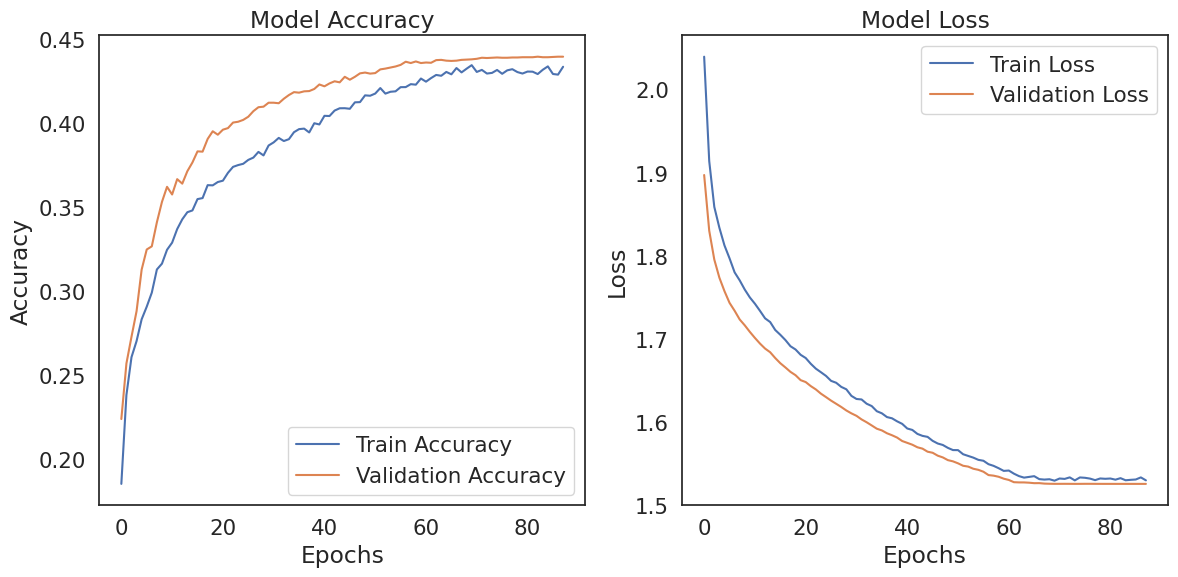

199/199 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step


<Figure size 1000x800 with 0 Axes>

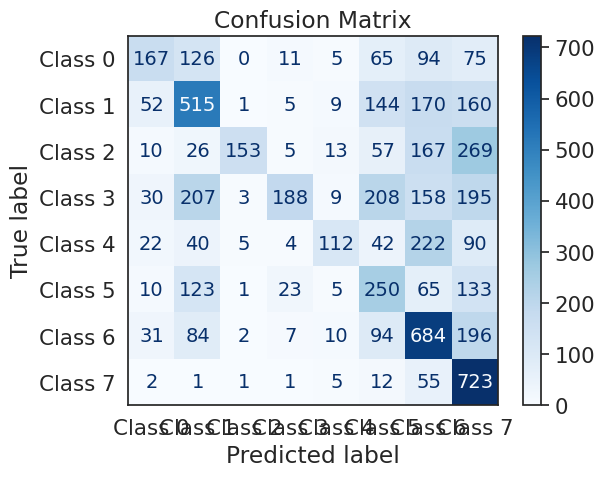

Modello salvato in: /content/gdrive/My Drive/FirstChallenge/models/model_resnet50_2new_fuma.keras


In [ ]:
# Loading previous model
model.summary()

# Constants
EPOCHS_INITIAL = 100

# Optimizer
sgd_with_momentum = tf.keras.optimizers.SGD(
    learning_rate=0.001,  # Learning rate
    momentum=0.9         # Momentum coefficient
)

# Callbacks
checkpoint = ModelCheckpoint(
    'path to save checkpoints',  # Path where the best model will be saved
    save_best_only=True,        # Save only the model with the highest validation accuracy
    monitor='val_accuracy',     # Metric to monitor for saving the best model
    mode='max',                 # Maximize validation accuracy
    verbose=True                # Print information about the saving process
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor for early stopping
    patience=7,                 # Stop training if validation accuracy doesn't improve for 7 epochs
    restore_best_weights=True   # Restore the model weights of the best epoch
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',     # Metric to monitor for reducing the learning rate
    factor=0.1,                 # Reduce learning rate by a factor of 10 when triggered
    patience=2,                 # Number of epochs with no improvement to wait before reducing LR
    min_lr=1e-8                 # Minimum learning rate allowed
)

# Compile the model
model.compile(optimizer=sgd_with_momentum, loss='categorical_crossentropy', metrics=['accuracy'])

# Training
history_initial = model.fit(
    X_train_equal, Y_train_equal,
    validation_data=(X_val_equal, Y_val_equal),
    epochs=EPOCHS_INITIAL,
    batch_size=64,  # Batch size for training
    callbacks=[checkpoint, early_stopping, reduce_lr]  # Add callbacks for checkpointing, early stopping, and LR scheduling
)

# Plot Training History
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_initial.history['accuracy'], label='Train Accuracy')
plt.plot(history_initial.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_initial.history['loss'], label='Train Loss')
plt.plot(history_initial.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Prediction on validation set
Y_val_pred = model.predict(X_val_equal)
Y_val_pred_classes = np.argmax(Y_val_pred, axis=1)
Y_val_true_classes = np.argmax(Y_val_equal, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(Y_val_true_classes, Y_val_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'C. {i}' for i in range(8)])

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Save the model
save_path = 'new model path'
model.save(save_path)
print(f"Model saved in: {save_path}")



# Execute the  augmented test set


In [ ]:
model = tf.keras.models.load_model('/gdrive/My Drive/FirstChallenge/models/model_EffNet_48.keras')

augmented_test_set = np.load("/content/gdrive/My Drive/FirstChallenge/AugmentedDatasets/augmented_test_set.npz")

X_test = augmented_test_set['data']
Y_test = augmented_test_set['labels']

X_test = X_test / 255.0

Y_test = to_categorical(Y_test, num_classes=8)

loss, accuracy = model.evaluate(X_test, Y_test, sample_weight=None, batch_size=32)

del X_test, Y_test, augmented_test_set

148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.1740 - loss: 2.2760


# Execute the test set

In [ ]:
model = tf.keras.models.load_model('/gdrive/My Drive/FirstChallenge/models/model_EffNet_48.keras')

test_set = np.load("/content/gdrive/My Drive/FirstChallenge/splitting dataset/validation/test_set/test_set.npz")

X_test = test_set['data']
Y_test = test_set['labels']

X_test = X_test / 255.0

Y_test = to_categorical(Y_test, num_classes=8)

loss, accuracy = model.evaluate(X_test, Y_test, batch_size=32)

del X_test, Y_test, test_set

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.9152 - loss: 0.2593
